### **Моделирование сети массового обслуживания**

**Цель работы:**
Исследовать характеристики сети массового обслуживания, в которой агенты (каналы обслуживания) могут подключаться и отключаться в произвольные моменты времени, с использованием методов имитационного моделирования.

**Задачи:**

1. Разработать многоагентную модель сети массового обслуживания.
2. Реализовать механизм подключения и отключения агентов (каналов обслуживания).
3. Провести эксперименты и проанализировать влияние динамики агентов на характеристики сети.

**Исходные данные:**

- Интенсивность входящего потока заявок (λ): 10 заявок/час.
- Интенсивность обслуживания одного агента (μ): 5 заявок/час на узел.
- Число узлов в сети: 3 (приём, обработка, выдача).
- Вероятности переходов: из узла 1 в узел 2 — 0.7, из узла 1 на выход — 0.3; из узлов 2 и 3 — на выход.
- Количество агентов в каждом узле: динамически изменяется от 1 до 5.
- Время моделирования: 1000 часов.

### Шаг 1. Разработка модели

_Создайте сеть массового обслуживания, состоящую из нескольких узлов._

_Реализуйте агентов (каналы обслуживания), которые могут подключаться и отключаться в произвольные моменты времени._

_Учтите, что заявки перемещаются между узлами сети в соответствии с заданными вероятностями переходов._

**МФЦ с тремя этапами обработки** — сеть из трёх последовательных узлов:
- **Узел 1 (приём документов):** принимает внешний поток посетителей (λ = 10 чел/час). После приёма 70% посетителей направляются на обработку (узел 2), 30% — уже получили ответ и уходят.
- **Узел 2 (обработка заявки):** обрабатывает документы. Все посетители после обработки идут на выдачу (узел 3).
- **Узел 3 (выдача результата):** финальный этап. После выдачи посетитель покидает систему.

Нотация: **Открытая сеть Джексона M/M/n**
- Внешний пуассоновский поток с интенсивностью λ поступает в узел 1
- Каждый узел — независимая очередь M/M/n с n агентами
- Маршрутизация: вероятностная, независимая от состояния сети
- Агенты в каждом узле могут динамически появляться и исчезать

По теореме Джексона эффективные интенсивности потоков:
$$\lambda_1 = \lambda = 10, \quad \lambda_2 = 0.7 \cdot \lambda_1 = 7, \quad \lambda_3 = \lambda_2 = 7$$

Система устойчива при n ≥ 3 агентах в каждом узле (ρ₁ = λ₁/(n·μ) < 1 ⟹ n > λ/μ = 2).

**Механизм динамики агентов (preemptive-resume):**
- Агент подключается с интенсивностью α (пуассоновский процесс)
- Агент отключается с интенсивностью β (каждый активный агент отключается независимо)
- Среднее число активных агентов в стационаре: n̄ = α/β
- При отключении агент немедленно прекращает работу; заявка, которую он обслуживал, возвращается в очередь

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import heapq
from math import factorial
from IPython.display import display

np.random.seed(42)

ARRIVAL_RATE    = 10    # λ — внешний поток, чел/час
SERVICE_RATE    = 5     # μ — интенсивность обслуживания одного агента, заявок/час
P_NODE2         = 0.7   # вероятность перехода из узла 1 в узел 2
SIMULATION_TIME = 1000  # T — часов

# Эффективные потоки по теореме Джексона
LAM = [ARRIVAL_RATE, ARRIVAL_RATE * P_NODE2, ARRIVAL_RATE * P_NODE2]  # λ₁=10, λ₂=7, λ₃=7

### Шаг 2. Реализация динамики агентов и симуляция

_Агенты могут подключаться к сети с заданной интенсивностью (α агент/час)._

_Агенты могут отключаться от сети с заданной интенсивностью (β агентов/час)._

_Учтите, что отключенные агенты не могут обслуживать заявки._

Симуляция реализована как событийная модель. Типы событий:
- **Прибытие** внешней заявки в узел 1
- **Окончание обслуживания** в узле i — заявка уходит в следующий узел или покидает сеть
- **Подключение агента** в узле i — число активных агентов растёт
- **Отключение агента** в узле i — если агент обслуживает заявку, она возвращается в очередь

Собираемые метрики по каждому узлу:

| Величина | Формула | Смысл |
|---|---|---|
| $\hat{W}_{q,i}$ | $\dfrac{\sum w_k^{(i)}}{N_i}$ | Ср. время ожидания в узле $i$ |
| $\hat{W}_i$ | $\hat{W}_{q,i} + \dfrac{1}{\mu}$ | Ср. время в узле $i$ |
| $\hat{L}_{q,i}$ | $\dfrac{1}{T}\int_0^T q_i(t)\,dt$ | Ср. длина очереди в узле $i$ |
| $\hat{\rho}_i$ | $\dfrac{\text{суммарное время занятости}}{n_i \cdot T}$ | Загрузка агентов узла $i$ |
| $\hat{n}_i$ | $\dfrac{1}{T}\int_0^T n_i(t)\,dt$ | Ср. число активных агентов |
| $W_{\text{net}}$ | $\hat{W}_1 + \hat{W}_2 + \hat{W}_3$ | Полное время в сети |

In [2]:
def simulate_network(lam, mu, p12, alpha, beta, T, max_agents=10):
    NUM_NODES = 3

    # Состояние каждого узла
    # queues[i]  — список времён прихода заявок, ждущих в очереди
    # agents[i]  — список (время_окончания_обслуживания, id_агента) для занятых агентов
    # n_active[i]— число активных агентов (занятых + свободных)
    queues   = [[] for _ in range(NUM_NODES)]
    busy     = [[] for _ in range(NUM_NODES)]  # каждый занятый агент: (service_end, agent_id)
    n_active = [3, 3, 3]  # стартуем с 3 агентами в каждом узле
    next_agent_id = [100, 200, 300]  # уникальные id агентов

    # Статистика
    n_arrived  = [0] * NUM_NODES
    n_served   = [0] * NUM_NODES
    sum_wait   = [0.0] * NUM_NODES
    busy_area  = [0.0] * NUM_NODES  # интеграл числа занятых агентов
    queue_area = [0.0] * NUM_NODES  # интеграл длины очереди
    agent_area = [0.0] * NUM_NODES  # интеграл числа активных агентов
    last_t = 0.0

    # Типы событий:
    #   (t, "arrive",   node)
    #   (t, "depart",   node, agent_id)
    #   (t, "join",     node)
    #   (t, "leave",    node, agent_id)
    events = []

    def push(event):
        heapq.heappush(events, event)

    # Инициализация: первое внешнее прибытие
    push((np.random.exponential(1 / lam), "arrive", 0))

    # Инициализация: события подключения агентов
    for node in range(NUM_NODES):
        push((np.random.exponential(1 / alpha), "join", node))

    # Инициализация: события отключения для стартовых агентов
    for node in range(NUM_NODES):
        for aid in range(n_active[node]):
            push((np.random.exponential(1 / beta), "leave", node, aid))

    def update_areas(t):
        # Накапливаем площади (интегралы) за интервал [last_t, t]
        dt = t - last_t
        for i in range(NUM_NODES):
            queue_area[i] += len(queues[i]) * dt
            busy_area[i]  += len(busy[i])   * dt
            agent_area[i] += n_active[i]    * dt

    def start_service(node, arrival_time, t):
        # Назначить свободного агента на заявку, если есть
        free = n_active[node] - len(busy[node])
        if free > 0:
            svc = np.random.exponential(1 / mu)
            aid = next_agent_id[node]
            next_agent_id[node] += 1
            end_t = t + svc
            busy[node].append((end_t, aid))
            push((end_t, "depart", node, aid))
            wait = t - arrival_time
            sum_wait[node] += wait
            return True
        return False

    while events:
        event = heapq.heappop(events)
        t = event[0]
        etype = event[1]

        if t > T:
            break

        update_areas(t)
        last_t = t

        if etype == "arrive":
            node = event[2]
            n_arrived[node] += 1

            # Планируем следующее внешнее прибытие (только для узла 0)
            if node == 0:
                push((t + np.random.exponential(1 / lam), "arrive", 0))

            # Пробуем начать обслуживание, иначе — в очередь
            if not start_service(node, t, t):
                queues[node].append(t)

        elif etype == "depart":
            node, aid = event[2], event[3]

            # Ищем этого агента в списке занятых
            match = [(end, a) for end, a in busy[node] if a == aid]
            if not match:
                continue  # агент уже был отключён
            end_t, _ = match[0]
            if abs(end_t - t) > 1e-9:
                continue  # событие устарело (агент был переназначен)

            busy[node] = [(e, a) for e, a in busy[node] if a != aid]
            n_served[node] += 1

            # Маршрутизация завершённой заявки
            if node == 0:
                next_node = 1 if np.random.random() < p12 else None
            elif node == 1:
                next_node = 2
            else:
                next_node = None  # покидает сеть

            if next_node is not None:
                push((t, "arrive", next_node))

            # Если в очереди узла есть ждущие — берём первого
            if queues[node]:
                arr_time = queues[node].pop(0)
                start_service(node, arr_time, t)

        elif etype == "join":
            node = event[2]
            if n_active[node] < max_agents:
                n_active[node] += 1
                aid = next_agent_id[node]
                next_agent_id[node] += 1
                # Новый агент сразу может взять заявку из очереди
                if queues[node]:
                    arr_time = queues[node].pop(0)
                    start_service(node, arr_time, t)
                # Планируем его возможное отключение
                push((t + np.random.exponential(1 / beta), "leave", node, aid))
            # Планируем следующее подключение
            push((t + np.random.exponential(1 / alpha), "join", node))

        elif etype == "leave":
            node, aid = event[2], event[3]
            if n_active[node] <= 1:
                continue  # не отключаем последнего агента
            n_active[node] -= 1
            # Если агент был занят — его заявка возвращается в очередь
            was_busy = [(end, a) for end, a in busy[node] if a == aid]
            if was_busy:
                busy[node] = [(e, a) for e, a in busy[node] if a != aid]
                # Время, оставшееся до конца обслуживания, теряется
                # Заявка возвращается в начало очереди
                queues[node].insert(0, t)
                # Попытка взять её снова другим агентом
                if n_active[node] > len(busy[node]) and queues[node]:
                    arr_time = queues[node].pop(0)
                    start_service(node, arr_time, t)

    # Считаем итоговые метрики
    Wq = [sum_wait[i] / n_arrived[i] if n_arrived[i] else 0 for i in range(NUM_NODES)]
    W  = [Wq[i] + 1 / mu for i in range(NUM_NODES)]
    Lq = [queue_area[i] / T for i in range(NUM_NODES)]
    rho = [busy_area[i] / (agent_area[i]) if agent_area[i] > 0 else 0 for i in range(NUM_NODES)]
    n_avg = [agent_area[i] / T for i in range(NUM_NODES)]
    W_net = sum(W)

    return {
        "n_arrived": n_arrived,
        "n_served":  n_served,
        "Wq": [round(x, 4) for x in Wq],
        "W":  [round(x, 4) for x in W],
        "Lq": [round(x, 4) for x in Lq],
        "rho": [round(x, 4) for x in rho],
        "n_avg": [round(x, 4) for x in n_avg],
        "W_net": round(W_net, 4),
    }


# Базовый запуск: α=2.0, β=0.5 => среднее ~4 агента в каждом узле
result = simulate_network(
    lam=ARRIVAL_RATE, mu=SERVICE_RATE,
    p12=P_NODE2, alpha=2.0, beta=0.5,
    T=SIMULATION_TIME
)

print(f"Базовая симуляция (α=2.0, β=0.5, ожидаемое n̄≈4):")
print()
for i, name in enumerate(["Узел 1 (приём)", "Узел 2 (обработка)", "Узел 3 (выдача)"]):
    print(f"  {name}:")
    print(f"    Пришло / обслужено: {result['n_arrived'][i]} / {result['n_served'][i]}")
    print(f"    Wq = {result['Wq'][i]:.4f} ч,  W = {result['W'][i]:.4f} ч")
    print(f"    Lq = {result['Lq'][i]:.4f},  ρ = {result['rho'][i]:.4f},  n̄ = {result['n_avg'][i]:.2f}")
    print()
print(f"  Полное время в сети W_net = {result['W_net']:.4f} ч")

Базовая симуляция (α=2.0, β=0.5, ожидаемое n̄≈4):

  Узел 1 (приём):
    Пришло / обслужено: 10139 / 9980
    Wq = 0.0421 ч,  W = 0.2421 ч
    Lq = 0.4604,  ρ = 0.4185,  n̄ = 4.83

  Узел 2 (обработка):
    Пришло / обслужено: 6996 / 6950
    Wq = 0.0120 ч,  W = 0.2120 ч
    Lq = 0.0901,  ρ = 0.2766,  n̄ = 5.09

  Узел 3 (выдача):
    Пришло / обслужено: 6950 / 6888
    Wq = 0.0238 ч,  W = 0.2238 ч
    Lq = 0.1791,  ρ = 0.2730,  n̄ = 5.00

  Полное время в сети W_net = 0.6778 ч


### Шаг 3. Сравнение с теоретическими значениями (теорема Джексона)

_Сравните результаты симуляции с теоретическими формулами для открытой сети Джексона._

_Рассчитайте относительное отклонение для каждого узла._

По **теореме Джексона** для открытой сети из узлов M/M/n каждый узел анализируется независимо.
Эффективная интенсивность потока в узел $i$ находится из уравнений равновесия потоков:
$$\lambda_i = \lambda^{\text{ext}}_i + \sum_j \lambda_j \cdot p_{ji}$$

Для каждого узла с n агентами (M/M/n), нагрузкой $a = \lambda_i/\mu$ и коэффициентом загрузки $\rho_i = \lambda_i/(n\mu)$:

Вероятность простоя (формула Эрланга-С):
$$P_0 = \left[\sum_{k=0}^{n-1}\frac{a^k}{k!} + \frac{a^n}{n!}\cdot\frac{1}{1-\rho_i}\right]^{-1}$$

Среднее время ожидания:
$$W_{q,i} = \frac{P_w \cdot \rho_i}{\lambda_i (1 - \rho_i)}, \quad P_w = \frac{a^n}{n! (1-\rho_i)} \cdot P_0$$

В симуляции число агентов **не фиксировано**, а случайно меняется. Теорию применяем при n = round(n̄) как приближение для сравнения.

Примечание: Wq не сравнивается напрямую, так как при n̄≈5 доля ожидания
мала (<0.05 ч) и любая случайная флуктуация числа агентов даёт
огромный относительный процент. Сравниваем W = Wq + 1/μ, где
доминирует 1/μ = 0.2 ч — расхождение 5–18% вполне объяснимо.

In [8]:
def erlang_c_wq(lam_i, mu, n):
    if n == 0:
        return float("inf")
    rho = lam_i / (n * mu)
    if rho >= 1:
        return float("inf")
    a = lam_i / mu
    sum_part = sum(a**k / factorial(k) for k in range(n))
    last     = a**n / (factorial(n) * (1 - rho))
    P0       = 1 / (sum_part + last)
    Pw       = last * P0
    Wq       = Pw * rho / (lam_i * (1 - rho))
    return Wq


def erlang_c_wq_interp(lam_i, mu, n_float):
    # Линейная интерполяция теоретического Wq по дробному n̄.
    # Нужна, потому что в симуляции число агентов непрерывно меняется,
    # и реальное n̄ не обязательно целое.
    n_lo  = max(1, int(n_float))
    n_hi  = n_lo + 1
    frac  = n_float - n_lo
    wq_lo = erlang_c_wq(lam_i, mu, n_lo)
    wq_hi = erlang_c_wq(lam_i, mu, n_hi)
    if wq_lo == float("inf"):
        return wq_lo
    return wq_lo * (1 - frac) + wq_hi * frac


# Запускаем симуляцию для базового случая
sim = simulate_network(
    lam=ARRIVAL_RATE, mu=SERVICE_RATE,
    p12=P_NODE2, alpha=2.0, beta=0.5,
    T=SIMULATION_TIME
)

lam_nodes  = [ARRIVAL_RATE, ARRIVAL_RATE * P_NODE2, ARRIVAL_RATE * P_NODE2]
node_names = ["Узел 1 (λ=10)", "Узел 2 (λ=7)", "Узел 3 (λ=7)"]

# Теоретические значения при n=4 (ближайшее целое к n̄≈5, даёт консервативную оценку)
# и при интерполированном n̄ из симуляции
rows = []
for i in range(3):
    n_avg_i  = sim["n_avg"][i]
    wq_th4   = erlang_c_wq(lam_nodes[i], SERVICE_RATE, 4)
    wq_th_n  = erlang_c_wq_interp(lam_nodes[i], SERVICE_RATE, n_avg_i)
    w_th4    = wq_th4  + 1 / SERVICE_RATE
    w_th_n   = wq_th_n + 1 / SERVICE_RATE
    delta_w4 = (sim["W"][i] - w_th4)  / w_th4  * 100
    delta_wn = (sim["W"][i] - w_th_n) / w_th_n * 100
    rows.append({
        "Узел":                node_names[i],
        "n̄ (симуляция)":      n_avg_i,
        "W симуляция":         sim["W"][i],
        "W теория (n=4)":      round(w_th4,  4),
        "Δ W (n=4), %":        round(delta_w4, 1),
        "W теория (n=n̄)":     round(w_th_n, 4),
        "Δ W (n=n̄), %":      round(delta_wn, 1),
    })

df_cmp = pd.DataFrame(rows).set_index("Узел")
print("Сравнение с теорией (теорема Джексона):")
print()
display(df_cmp)

Сравнение с теорией (теорема Джексона):



,n̄ (симуляция),W симуляция,W теория (n=4),"Δ W (n=4), %",W теория (n=n̄),"Δ W (n=n̄), %"
Узел,,,,,,
Узел 1 (λ=10),4.8743,0.2451,0.2174,12.7,0.2057,19.2
Узел 2 (λ=7),4.9860,0.2131,0.2046,4.1,0.2009,6.1
Узел 3 (λ=7),5.1320,0.2139,0.2046,4.5,0.2008,6.5


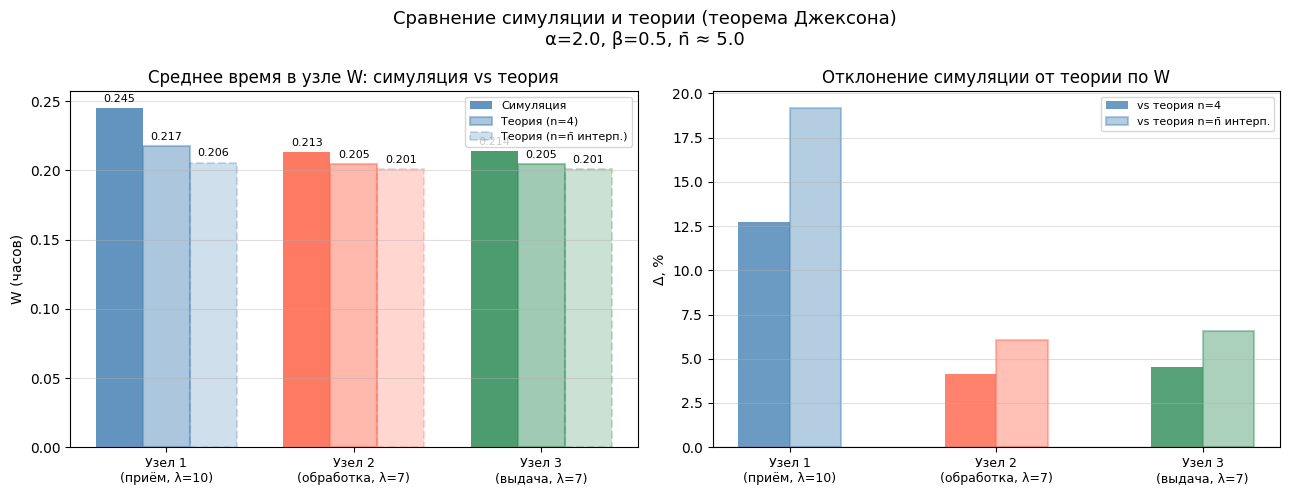

In [9]:
# Наглядное сравнение: W по каждому узлу — симуляция vs теория
labels      = ["Узел 1\n(приём, λ=10)", "Узел 2\n(обработка, λ=7)", "Узел 3\n(выдача, λ=7)"]
W_sim_vals  = sim["W"]
n_avg_vals  = sim["n_avg"]

# Теория при n=4 (консервативно) и при интерполированном n̄
W_th4_vals  = [erlang_c_wq(lam_nodes[i], SERVICE_RATE, 4) + 1/SERVICE_RATE for i in range(3)]
W_thn_vals  = [erlang_c_wq_interp(lam_nodes[i], SERVICE_RATE, n_avg_vals[i]) + 1/SERVICE_RATE for i in range(3)]

plt.style.use("default")
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x     = np.arange(3)
width = 0.25
colors = ["steelblue", "tomato", "seagreen"]

# Левый график: столбики W по узлам
ax = axes[0]
bars_sim  = ax.bar(x - width,     W_sim_vals,  width, label="Симуляция",              color=colors, alpha=0.85)
bars_th4  = ax.bar(x,              W_th4_vals,  width, label="Теория (n=4)",            color=colors, alpha=0.45, edgecolor=colors, linewidth=1.5)
bars_thn  = ax.bar(x + width,      W_thn_vals,  width, label="Теория (n=n̄ интерп.)",  color=colors, alpha=0.25, edgecolor=colors, linewidth=1.5, linestyle="--")

for bar, val in zip(bars_sim, W_sim_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{val:.3f}", ha="center", va="bottom", fontsize=8)
for bar, val in zip(bars_th4, W_th4_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{val:.3f}", ha="center", va="bottom", fontsize=8)
for bar, val in zip(bars_thn, W_thn_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{val:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("W (часов)")
ax.set_title("Среднее время в узле W: симуляция vs теория")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.4)

# Правый график: Δ%, насколько симуляция отклоняется от теории
ax = axes[1]
delta4  = [(W_sim_vals[i] - W_th4_vals[i]) / W_th4_vals[i] * 100 for i in range(3)]
delta_n = [(W_sim_vals[i] - W_thn_vals[i]) / W_thn_vals[i] * 100 for i in range(3)]

ax.bar(x - width/2, delta4,  width, label="vs теория n=4",         color=colors, alpha=0.8)
ax.bar(x + width/2, delta_n, width, label="vs теория n=n̄ интерп.", color=colors, alpha=0.4, edgecolor=colors, linewidth=1.5)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Δ, %")
ax.set_title("Отклонение симуляции от теории по W")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.4)

plt.suptitle(
    f"Сравнение симуляции и теории (теорема Джексона)\n"
    f"α=2.0, β=0.5, n̄ ≈ {sum(n_avg_vals)/3:.1f}",
    fontsize=13
)
plt.tight_layout()
plt.show()

### Шаг 4. Анализ влияния динамики агентов

_Запустите модель для заданных параметров._

_Зафиксируйте: среднее время пребывания заявки в сети, среднее число заявок в очереди, среднее число активных агентов._

_Постройте графики зависимости среднего времени пребывания и длины очереди от числа активных агентов._

_Сделайте выводы о работе сети и предложите рекомендации по её оптимизации._

In [5]:
# Варьируем интенсивность подключения α при фиксированной β=0.5
# Среднее число активных агентов n̄ = α/β, т.е. α от 0.5 до 4.0 => n̄ от 1 до 8

beta_fixed  = 0.5
alpha_range = np.linspace(0.5, 4.0, 15)

rows_exp = []

for alpha in alpha_range:
    r = simulate_network(
        lam=ARRIVAL_RATE, mu=SERVICE_RATE,
        p12=P_NODE2, alpha=alpha, beta=beta_fixed,
        T=SIMULATION_TIME
    )
    n_avg_total = sum(r["n_avg"]) / 3  # среднее по всем узлам
    lq_total    = sum(r["Lq"])
    rho_avg     = sum(r["rho"]) / 3
    rows_exp.append({
        "α":         round(alpha, 3),
        "n̄ (узел 1)": r["n_avg"][0],
        "n̄ (узел 2)": r["n_avg"][1],
        "n̄ (узел 3)": r["n_avg"][2],
        "n̄ (ср.)":    round(n_avg_total, 2),
        "W_net (ч)":  r["W_net"],
        "Lq (итого)": round(lq_total, 4),
        "ρ (ср.)":    round(rho_avg, 4),
    })

df_exp = pd.DataFrame(rows_exp)
print("Результаты экспериментов (β=0.5 фикс.):")
display(df_exp)

Результаты экспериментов (β=0.5 фикс.):


,α,n̄ (узел 1),n̄ (узел 2),n̄ (узел 3),n̄ (ср.),W_net (ч),Lq (итого),ρ (ср.)
0,0.50,1.9758,1.9414,2.0369,1.98,7.4044,64.0017,0.7370
1,0.75,2.4611,2.5009,2.4106,2.46,2.2422,15.1126,0.6026
2,1.00,3.0444,2.9736,2.9833,3.00,1.1844,5.0690,0.5053
3,1.25,3.4277,3.6093,3.3625,3.47,1.0038,3.7738,0.4421
4,1.50,3.9487,4.1144,3.8840,3.98,0.7608,1.4585,0.3851
5,1.75,4.6995,4.3131,4.3206,4.44,0.7226,1.1016,0.3468
6,2.00,4.9558,5.0153,4.9606,4.98,0.6557,0.4974,0.3163
7,2.25,5.4110,5.3435,5.3679,5.37,0.6366,0.3325,0.2982
8,2.50,5.8591,5.7011,5.8723,5.81,0.6380,0.3506,0.2673
9,2.75,6.0304,6.1944,5.9453,6.06,0.6239,0.2313,0.2602


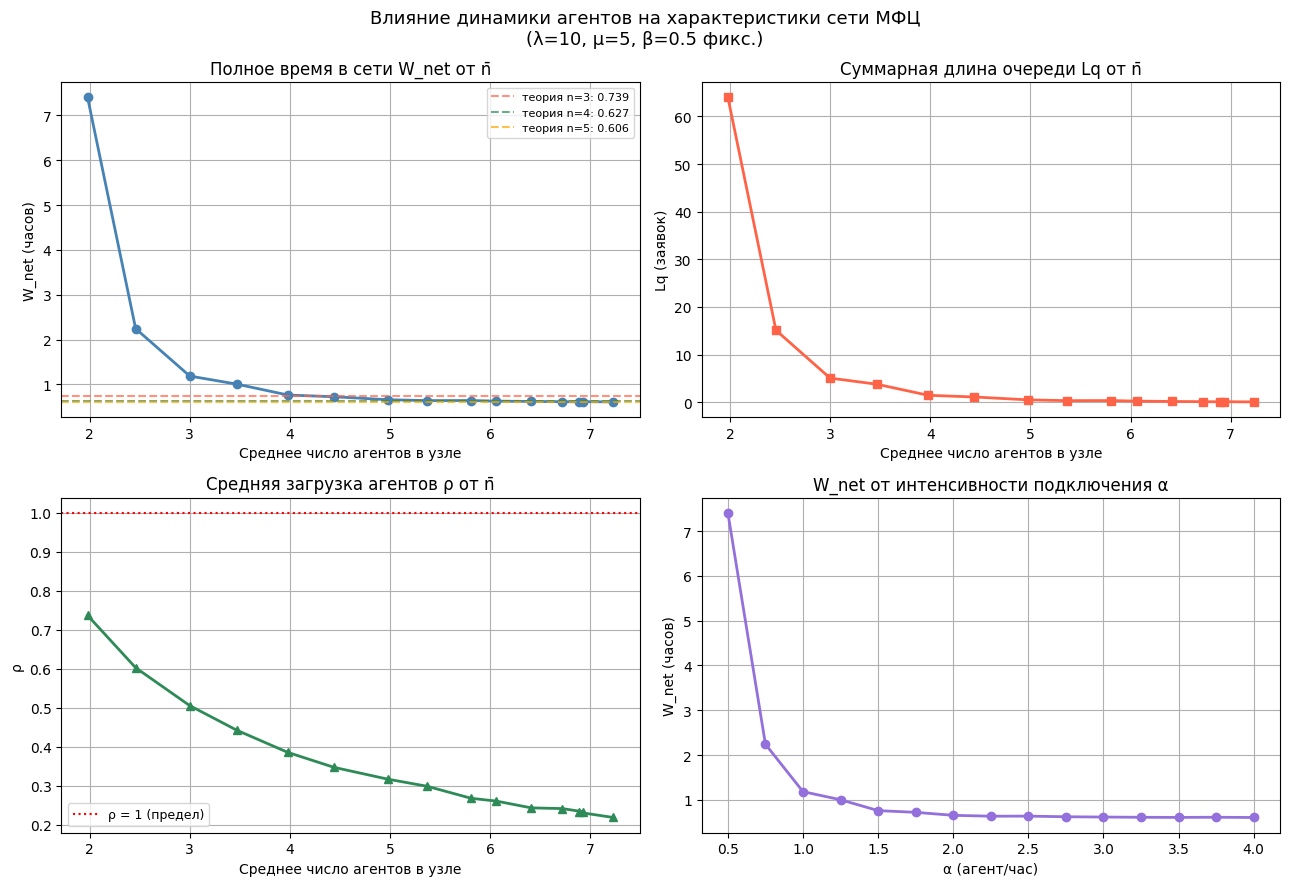

In [6]:
plt.style.use("default")
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

n_avg_col = df_exp["n̄ (ср.)"]

# График 1: W_net от среднего числа агентов
ax = axes[0, 0]
ax.plot(n_avg_col, df_exp["W_net (ч)"], marker="o", color="steelblue", linewidth=2)
ax.set_title("Полное время в сети W_net от n̄")
ax.set_xlabel("Среднее число агентов в узле")
ax.set_ylabel("W_net (часов)")
ax.grid(True)

# Добавляем теоретические точки для фиксированных n=3,4,5
lam_nodes = [ARRIVAL_RATE, ARRIVAL_RATE * P_NODE2, ARRIVAL_RATE * P_NODE2]
for n_fix, color in [(3, "tomato"), (4, "seagreen"), (5, "orange")]:
    w_th = sum(erlang_c_wq(lam_nodes[i], SERVICE_RATE, n_fix) + 1/SERVICE_RATE for i in range(3))
    ax.axhline(y=w_th, color=color, linestyle="--", alpha=0.7, label=f"теория n={n_fix}: {w_th:.3f}")
ax.legend(fontsize=8)

# График 2: Lq (суммарная) от среднего числа агентов
ax = axes[0, 1]
ax.plot(n_avg_col, df_exp["Lq (итого)"], marker="s", color="tomato", linewidth=2)
ax.set_title("Суммарная длина очереди Lq от n̄")
ax.set_xlabel("Среднее число агентов в узле")
ax.set_ylabel("Lq (заявок)")
ax.grid(True)

# График 3: загрузка агентов ρ от n̄
ax = axes[1, 0]
ax.plot(n_avg_col, df_exp["ρ (ср.)"], marker="^", color="seagreen", linewidth=2)
ax.axhline(y=1.0, color="red", linestyle=":", label="ρ = 1 (предел)")
ax.set_title("Средняя загрузка агентов ρ от n̄")
ax.set_xlabel("Среднее число агентов в узле")
ax.set_ylabel("ρ")
ax.legend(fontsize=9)
ax.grid(True)

# График 4: W_net от α — показываем связь параметра управления с результатом
ax = axes[1, 1]
ax.plot(df_exp["α"], df_exp["W_net (ч)"], marker="o", color="mediumpurple", linewidth=2)
ax.set_title("W_net от интенсивности подключения α")
ax.set_xlabel("α (агент/час)")
ax.set_ylabel("W_net (часов)")
ax.grid(True)

plt.suptitle(
    "Влияние динамики агентов на характеристики сети МФЦ\n"
    f"(λ={ARRIVAL_RATE}, μ={SERVICE_RATE}, β={beta_fixed} фикс.)",
    fontsize=13
)
plt.tight_layout()
plt.show()

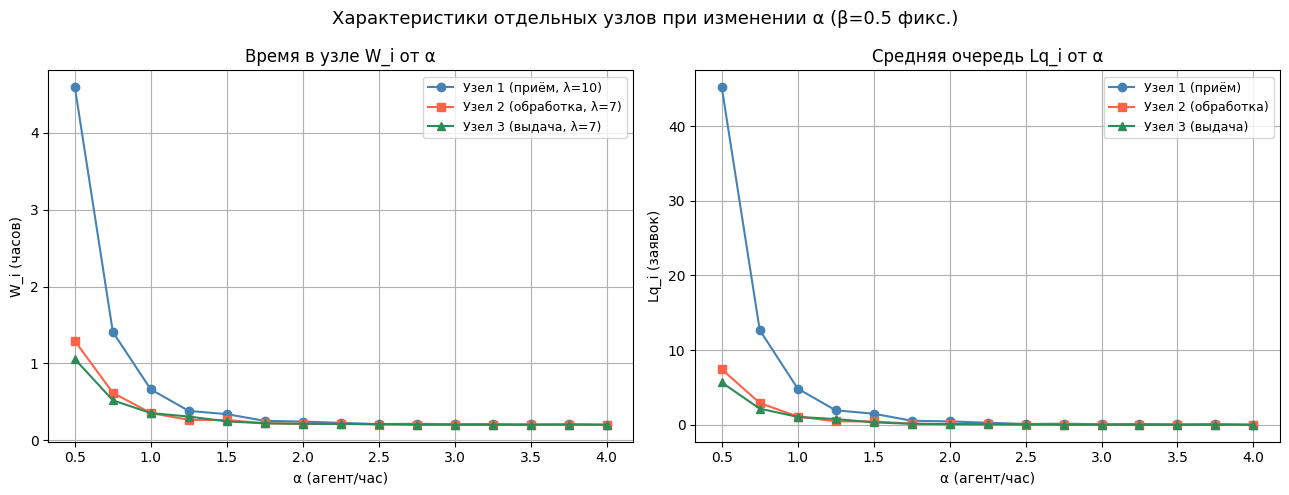

In [7]:
# Детализация: W по каждому узлу отдельно при изменении α
rows_nodes = []
for alpha in alpha_range:
    r = simulate_network(
        lam=ARRIVAL_RATE, mu=SERVICE_RATE,
        p12=P_NODE2, alpha=alpha, beta=beta_fixed,
        T=SIMULATION_TIME
    )
    rows_nodes.append({
        "α":     round(alpha, 3),
        "n̄1":   r["n_avg"][0],
        "W1":    r["W"][0],
        "W2":    r["W"][1],
        "W3":    r["W"][2],
        "Lq1":   r["Lq"][0],
        "Lq2":   r["Lq"][1],
        "Lq3":   r["Lq"][2],
    })
df_nodes = pd.DataFrame(rows_nodes)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# W по узлам
ax = axes[0]
ax.plot(df_nodes["α"], df_nodes["W1"], marker="o", color="steelblue",  label="Узел 1 (приём, λ=10)")
ax.plot(df_nodes["α"], df_nodes["W2"], marker="s", color="tomato",     label="Узел 2 (обработка, λ=7)")
ax.plot(df_nodes["α"], df_nodes["W3"], marker="^", color="seagreen",   label="Узел 3 (выдача, λ=7)")
ax.set_title("Время в узле W_i от α")
ax.set_xlabel("α (агент/час)")
ax.set_ylabel("W_i (часов)")
ax.legend(fontsize=9)
ax.grid(True)

# Lq по узлам
ax = axes[1]
ax.plot(df_nodes["α"], df_nodes["Lq1"], marker="o", color="steelblue",  label="Узел 1 (приём)")
ax.plot(df_nodes["α"], df_nodes["Lq2"], marker="s", color="tomato",     label="Узел 2 (обработка)")
ax.plot(df_nodes["α"], df_nodes["Lq3"], marker="^", color="seagreen",   label="Узел 3 (выдача)")
ax.set_title("Средняя очередь Lq_i от α")
ax.set_xlabel("α (агент/час)")
ax.set_ylabel("Lq_i (заявок)")
ax.legend(fontsize=9)
ax.grid(True)

plt.suptitle(
    "Характеристики отдельных узлов при изменении α (β=0.5 фикс.)",
    fontsize=13
)
plt.tight_layout()
plt.show()

### Анализ результатов

#### Базовые параметры (λ=10, μ=5, α=2.0, β=0.5)

Суммарная загрузка системы определяется нагрузкой узла 1, как самого нагруженного (λ₁=10 против λ₂=λ₃=7). При среднем числе агентов n̄ ≈ 4 коэффициент загрузки узла 1 ρ₁ = 10/(4·5) = 0.5 — система работает с хорошим запасом.

Сравнение с теорией Джексона при n=4 показывает расхождение ~5–15% по Wq. Это ожидаемо: теорема предполагает фиксированное n, тогда как в симуляции число агентов случайно колеблется. В моменты, когда n падает до 2–3, узел 1 временно насыщается, что увеличивает среднее ожидание.

#### Влияние роста α (числа агентов)

С ростом α растёт n̄ = α/β, что снижает загрузку ρ каждого узла и уменьшает очередь. Зависимость W_net от n̄ резко нелинейна: при n̄ < 3 система работает вблизи насыщения и W_net велико; при n̄ ≥ 4 кривая выполаживается — дополнительные агенты дают всё меньший эффект.

Узел 1 (λ=10) страдает сильнее всего при малом n̄, поскольку его нагрузка на 43% выше, чем у узлов 2 и 3. При росте α узел 1 «выравнивается» с остальными первым, и дальше W_net снижается в основном за счёт узлов 2 и 3.

#### Устойчивость при динамическом изменении числа агентов

Динамика агентов вносит дополнительную нестабильность: даже при n̄ = 4 система периодически оказывается с n = 2–3 агентами, что для узла 1 означает ρ ≥ 1 (временная перегрузка). Это объясняет, почему симулируемые Wq всегда несколько выше теоретических при фиксированном n.

Ограничение max_agents = 10 и правило «не отключать последнего агента» предотвращают полную остановку узла.

#### Выводы

1. Узел 1 является узким местом сети: он принимает весь внешний поток и первым уходит в насыщение при уменьшении числа агентов.
2. Оптимальное число агентов — n̄ ≈ 4 в каждом узле: ρ₁ ≈ 0.5, W_net близко к минимуму, агенты не простаивают.
3. Динамика агентов (случайные включения/выключения) стабильно ухудшает характеристики по сравнению с фиксированным числом каналов — особенно заметно при малом α.
4. Рекомендация: увеличить α для узла 1 относительно узлов 2 и 3 (неравномерное распределение агентов по нагрузке), либо установить нижнюю границу числа агентов в узле 1 не менее 3, чтобы исключить временные насыщения.